# 03 · Feature Engineering & Customer Segmentation
The feature functions are in `src/features.py` so the production pipeline (notebook 06) builds them the same way.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.ensemble import HistGradientBoostingClassifier

from src.features import add_application_features, aggregate_bureau, add_bureau_features

In [2]:
df = pd.read_csv("../data/cleaned_application_train.csv")
train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=df["TARGET"], random_state=42)

# 1. Features from the main table
| Feature | Rationale |
|---|---|
| `CREDIT_INCOME_RATIO` = credit / income | leverage |
| `ANNUITY_INCOME_RATIO` = annuity / income | share of income going to the payment |
| `CREDIT_TERM` = annuity / credit | proxy for loan length |
| `DAYS_EMPLOYED_RATIO` = days employed / days alive | job stability relative to age |
| `INCOME_PER_PERSON` = income / family members | household capacity |
| `EXT_SOURCE_MEAN`, `EXT_SOURCE_STD` | consensus and disagreement of the 3 bureau scores |
| `AGE`, `AGE_BUCKET` | readable age, and age bands |

In [3]:
df = add_application_features(df)
df["AGE_BUCKET"] = pd.cut(df["AGE"], bins=[20, 30, 40, 50, 60, 70, 100], labels=False)

engineered = ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "CREDIT_TERM", "DAYS_EMPLOYED_RATIO",
              "INCOME_PER_PERSON", "EXT_SOURCE_MEAN", "EXT_SOURCE_STD", "AGE"]
df[engineered].corrwith(df["TARGET"]).abs().sort_values(ascending=False).round(4)

EXT_SOURCE_MEAN         0.2209
AGE                     0.0782
EXT_SOURCE_STD          0.0778
DAYS_EMPLOYED_RATIO     0.0496
INCOME_PER_PERSON       0.0149
ANNUITY_INCOME_RATIO    0.0143
CREDIT_TERM             0.0127
CREDIT_INCOME_RATIO     0.0077
dtype: float64

**`EXT_SOURCE_MEAN` (0.22) is more correlated with default than any single external score (best 0.18).** The ratios look weak on a straight correlation; the model decides whether they help in combination.

# 2. Aggregation features from bureau.csv
Aggregate to one row per applicant, then **left** join so applicants without a bureau record are kept (counts = 0, plus a `BUREAU_NO_HISTORY` flag).

In [4]:
bureau = pd.read_csv("../data/bureau.csv")
df = add_bureau_features(df, aggregate_bureau(bureau))

# average credit age has no natural zero -> training median
df["BUREAU_DAYS_CREDIT_MEAN"] = df["BUREAU_DAYS_CREDIT_MEAN"].fillna(df.loc[train_idx, "BUREAU_DAYS_CREDIT_MEAN"].median())

bureau_feats = ["BUREAU_RECORD_COUNT", "BUREAU_ACTIVE_COUNT", "BUREAU_DAYS_CREDIT_MEAN", "BUREAU_OVERDUE_MAX", "BUREAU_NO_HISTORY"]
df[bureau_feats].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
BUREAU_RECORD_COUNT,307511.0,4.77,4.50,0.0,1.0,4.00,7.00,116.0
BUREAU_ACTIVE_COUNT,307511.0,1.76,1.80,0.0,0.0,1.00,3.00,32.0
BUREAU_DAYS_CREDIT_MEAN,307511.0,-1078.37,521.58,-2922.0,-1362.6,-1050.38,-734.63,0.0
BUREAU_OVERDUE_MAX,307511.0,158.49,13318.81,0.0,0.0,0.00,0.00,3756681.0
BUREAU_NO_HISTORY,307511.0,0.14,0.35,0.0,0.0,0.00,0.00,1.0


# 3. Encoding
- `CODE_GENDER` is **dropped**: sex can't be used in a credit decision.
- **Ordinal** for `NAME_EDUCATION_TYPE` (ordered).
- **One-hot** for categories with < 10 levels.
- **Frequency** encoding for the rest (`OCCUPATION_TYPE` 18 levels, `ORGANIZATION_TYPE` 58), learned on the training rows.

In [ ]:
df = df.drop(columns=["CODE_GENDER"])

education_order = {"Lower secondary": 0, "Secondary / secondary special": 1,
                   "Incomplete higher": 2, "Higher education": 3, "Academic degree": 4}
df["NAME_EDUCATION_TYPE"] = df["NAME_EDUCATION_TYPE"].map(education_order)

cat_cols = df.select_dtypes(include="object").columns
low_card = [c for c in cat_cols if df[c].nunique() < 10]
high_card = [c for c in cat_cols if df[c].nunique() >= 10]

df = pd.get_dummies(df, columns=low_card, drop_first=True, dtype=int)
for col in high_card:
    freq = df.loc[train_idx, col].value_counts(normalize=True)
    df[col + "_FREQ"] = df[col].map(freq).fillna(0)
df = df.drop(columns=high_card)

print("one-hot:", low_card)
print("frequency:", high_card)
print("shape:", df.shape)

one-hot: ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
frequency: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
shape: (307511, 225)


In [6]:
df.to_csv("../data/preprocessed_train.csv", index=False)

# 4. Customer segmentation

In [7]:
cluster_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "CREDIT_INCOME_RATIO", "AGE", "EXT_SOURCE_MEAN", "BUREAU_RECORD_COUNT"]

# clip the top 1% so extreme values don't get a cluster of their own
X_cluster = df[cluster_features].clip(upper=df[cluster_features].quantile(0.99), axis=1)
X_scaled = StandardScaler().fit_transform(X_cluster)

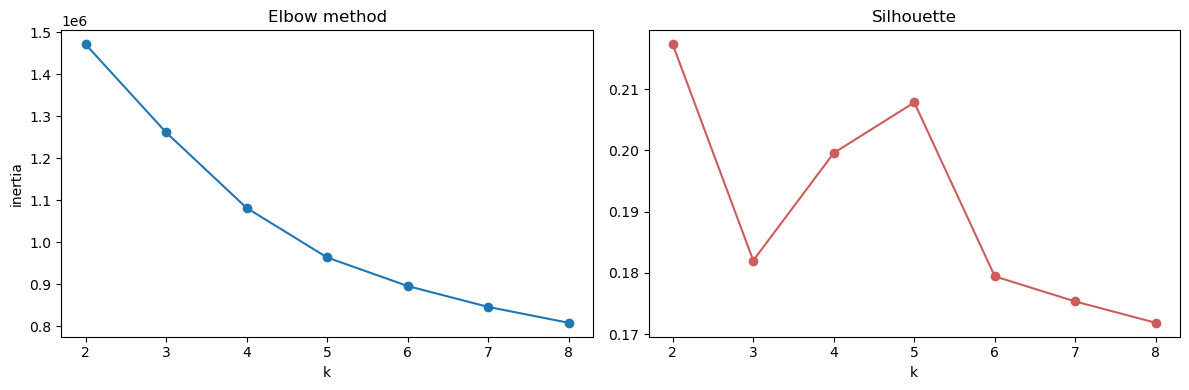

In [8]:
inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, "o-"); ax1.set_title("Elbow method"); ax1.set_xlabel("k"); ax1.set_ylabel("inertia")
ax2.plot(K_range, silhouettes, "o-", color="indianred"); ax2.set_title("Silhouette"); ax2.set_xlabel("k")
plt.tight_layout()
plt.show()

**k = 5**: the elbow flattens after 5, and it has the best silhouette in the 3–7 range (k = 2 is higher but too coarse to act on).

In [9]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df["customer_segment"] = km.fit_predict(X_scaled)

profile = df.groupby("customer_segment")[cluster_features + ["TARGET"]].mean().rename(columns={"TARGET": "DEFAULT_RATE"})
profile.insert(0, "applicants", df["customer_segment"].value_counts())
profile.round(3)

,applicants,AMT_INCOME_TOTAL,AMT_CREDIT,CREDIT_INCOME_RATIO,AGE,EXT_SOURCE_MEAN,BUREAU_RECORD_COUNT,DEFAULT_RATE
customer_segment,,,,,,,,
0,86859,144284.564,382556.515,2.819,32.489,0.437,2.976,0.132
1,57528,137951.761,1059048.547,8.178,46.389,0.538,4.091,0.064
2,85936,132411.021,376027.340,3.015,53.658,0.564,3.304,0.049
3,38954,340042.101,968242.592,3.101,43.263,0.553,4.880,0.053
4,38234,175157.954,523681.949,3.186,45.092,0.480,13.010,0.090


# 5. Does the segment improve the model?

In [11]:
y = df["TARGET"]
X_base = df.drop(columns=["SK_ID_CURR", "TARGET", "customer_segment"])
X_seg = pd.concat([X_base, pd.get_dummies(df["customer_segment"], prefix="segment", drop_first=True, dtype=int)], axis=1)

for name, X in [("without segment", X_base), ("with segment", X_seg)]:
    model = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
    model.fit(X.loc[train_idx], y.loc[train_idx])
    auroc = roc_auc_score(y.loc[test_idx], model.predict_proba(X.loc[test_idx])[:, 1])
    print(f"AUROC {name}: {auroc:.4f}")

AUROC without segment: 0.7678
AUROC with segment: 0.7667


**No improvement** (0.7678 → 0.7667): the segment only summarises six columns the model already has. Kept for business insight, not added to the model.